# RAG System for Customer Service Intent Classification

This notebook implements a complete Retrieval-Augmented Generation (RAG) system that combines:
1. **Document Retrieval**: FAISS-based semantic search for relevant customer service knowledge
2. **Intent Classification**: ML-based intent detection from customer messages
3. **Prompt Engineering**: Context-aware response generation

## Architecture Overview
```
Customer Message → Intent Classification → Document Retrieval → Prompt Generation → Response
                        ↓                         ↓                    ↓
                  ML Model (trained)      FAISS Vector DB      Intent-Specific Templates
```

## 1. Setup and Dependencies

In [1]:
# Import required libraries
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project paths
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'models' / 'trained'))

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

print("✓ Dependencies loaded")
print(f"Project root: {project_root}")

✓ Dependencies loaded
Project root: /Users/ole-michael.ekornrud/Documents/Workspace/CSIC-LLM-Prompting


## 2. Knowledge Base Creation

We'll create a knowledge base from the customer service tweets dataset that can be retrieved during response generation.

In [2]:
# Load the intent-labeled dataset
data_path = project_root / 'data' / 'processed' / 'tweets_with_intents.csv'

print("Loading dataset...")
df = pd.read_csv(data_path)

print(f"\n✓ Loaded {len(df):,} records")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nIntent Distribution:")
print(df['intent'].value_counts())

# Show sample data
df.head()

Loading dataset...

✓ Loaded 1,482,951 records

Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id', 'intent']

Intent Distribution:
intent
General_Inquiry      838821
Compliments          129577
Delivery_Issues      125423
Product_Questions    116448
Billing_Problems      98243
Account_Issues        60746
Complaints            47835
Technical_Issues      37980
Service_Issues        27878
Name: count, dtype: int64


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,intent
0,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,and how do you propose we do that,NaN,1.0,Product_Questions
1,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,i have sent several private messages and no on...,1,4.0,Delivery_Issues
2,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,i did.,4,6.0,General_Inquiry
3,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,is the worst customer service,"9,6,10",NaN,Complaints
4,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,you gonna magically change your connectivity f...,"11,13,14",15.0,General_Inquiry


In [3]:
class CustomerServiceKnowledgeBase:
    """
    Knowledge base for customer service responses
    Stores intent-specific examples and solutions
    """
    
    def __init__(self, df):
        self.df = df
        self.intent_examples = self._build_intent_examples()
        self.intent_solutions = self._build_solution_templates()
        
    def _build_intent_examples(self):
        """Build representative examples for each intent"""
        examples = {}
        for intent in self.df['intent'].unique():
            intent_data = self.df[self.df['intent'] == intent]
            # Get diverse examples (by length)
            intent_data['text_len'] = intent_data['text'].str.len()
            
            # Sample from different length quantiles
            sample_examples = []
            for q in [0.25, 0.5, 0.75]:
                quantile_val = intent_data['text_len'].quantile(q)
                closest_idx = (intent_data['text_len'] - quantile_val).abs().idxmin()
                sample_examples.append(intent_data.loc[closest_idx, 'text'])
            
            examples[intent] = sample_examples
            
        return examples
    
    def _build_solution_templates(self):
        """Define solution templates for each intent category"""
        return {
            'Account_Issues': {
                'immediate_solution': 'Try resetting your password using the "Forgot Password" link on the login page',
                'backup_solution': 'Clear your browser cache and cookies, then try logging in again',
                'additional_resources': 'Our account recovery team is available 24/7 at support@company.com'
            },
            'Billing_Payment': {
                'immediate_solution': 'Check your payment method is up to date in Account Settings',
                'backup_solution': 'Verify the charge on your bank statement matches our billing cycle',
                'additional_resources': 'Contact billing support for detailed invoice breakdown'
            },
            'Service_Outage': {
                'immediate_solution': 'Check our status page at status.company.com for real-time updates',
                'backup_solution': 'Try accessing from a different network or device',
                'additional_resources': 'Follow @CompanySupport for live outage notifications'
            },
            'Product_Feature': {
                'immediate_solution': 'Visit our help center at help.company.com for feature tutorials',
                'backup_solution': 'Check if your app/software is updated to the latest version',
                'additional_resources': 'Join our community forum for tips from other users'
            },
            'Complaint_Feedback': {
                'immediate_solution': 'I\'ve escalated your feedback to our quality assurance team',
                'backup_solution': 'We\'ll follow up with you within 24 hours via email',
                'additional_resources': 'Your feedback case number is #CS-' + str(np.random.randint(10000, 99999))
            },
            'Delivery_Shipping': {
                'immediate_solution': 'Track your order using the tracking number sent to your email',
                'backup_solution': 'Contact the shipping carrier directly for delivery updates',
                'additional_resources': 'Orders typically arrive within 3-5 business days'
            },
            'Refund_Cancellation': {
                'immediate_solution': 'Initiate a refund request in your order history section',
                'backup_solution': 'Refunds are processed within 5-7 business days to your original payment method',
                'additional_resources': 'Review our refund policy at company.com/refunds'
            },
            'General_Inquiry': {
                'immediate_solution': 'Browse our FAQ section for answers to common questions',
                'backup_solution': 'Describe your specific need so I can direct you to the right department',
                'additional_resources': 'Our customer service team is here to help 24/7'
            }
        }
    
    def get_examples(self, intent, n=3):
        """Get example messages for a given intent"""
        return self.intent_examples.get(intent, [])[:n]
    
    def get_solutions(self, intent):
        """Get solution templates for a given intent"""
        return self.intent_solutions.get(intent, self.intent_solutions['General_Inquiry'])

# Initialize knowledge base
kb = CustomerServiceKnowledgeBase(df)
print("✓ Knowledge Base initialized")
print(f"\nIntents covered: {list(kb.intent_solutions.keys())}")

✓ Knowledge Base initialized

Intents covered: ['Account_Issues', 'Billing_Payment', 'Service_Outage', 'Product_Feature', 'Complaint_Feedback', 'Delivery_Shipping', 'Refund_Cancellation', 'General_Inquiry']


## 3. FAISS Vector Store for Semantic Search

We'll use FAISS (Facebook AI Similarity Search) to create a vector database for efficient semantic retrieval.

In [52]:
# Install required packages if not already installed
import subprocess
import sys

def install_if_missing(package):
    try:
        __import__(package)
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call(["uv", "pip", "install", package])
        print(f"✓ {package} installed")

# Install FAISS
install_if_missing('faiss-cpu')
install_if_missing('sentence-transformers')

Installing faiss-cpu...
✓ faiss-cpu installed
Installing sentence-transformers...
✓ sentence-transformers installed


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Using Python 3.13.5 environment at: /Users/ole-michael.ekornrud/Documents/Workspace/CSIC-LLM-Prompting/.venv
Audited 1 package in 11ms
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Using Python 3.13.5 environment at: /Users/ole-michael.ekornrud/Documents/Workspace/CSIC-LLM-Prompting/.venv
Audited 1 package in 15ms


In [38]:
import faiss
from sentence_transformers import SentenceTransformer
from typing import List, Tuple

class FAISSVectorStore:
    """
    FAISS-based vector store for semantic search
    Uses sentence transformers for embeddings
    """
    
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        """Initialize with a sentence transformer model"""
        print(f"Loading embedding model: {model_name}...")
        self.encoder = SentenceTransformer(model_name)
        self.dimension = self.encoder.get_sentence_embedding_dimension()
        self.index = None
        self.documents = []
        self.metadata = []
        print(f"✓ Embedding model loaded (dimension: {self.dimension})")
    
    def build_index(self, texts: List[str], metadata: List[dict] = None):
        """Build FAISS index from texts"""
        print(f"\nBuilding FAISS index for {len(texts)} documents...")
        
        # Store documents and metadata
        self.documents = texts
        self.metadata = metadata if metadata else [{} for _ in texts]
        
        # Generate embeddings
        print("Generating embeddings...")
        embeddings = self.encoder.encode(
            texts,
            show_progress_bar=True,
            batch_size=32
        )
        
        # Create FAISS index
        self.index = faiss.IndexFlatL2(self.dimension)
        self.index.add(embeddings.astype('float32'))
        
        print(f"✓ FAISS index built with {self.index.ntotal} vectors")
    
    def search(self, query: str, k: int = 5) -> List[Tuple[str, dict, float]]:
        """Search for similar documents"""
        if self.index is None:
            raise ValueError("Index not built. Call build_index() first.")
        
        # Encode query
        query_embedding = self.encoder.encode([query])
        
        # Search
        distances, indices = self.index.search(
            query_embedding.astype('float32'), k
        )
        
        # Return results
        results = []
        for dist, idx in zip(distances[0], indices[0]):
            results.append((
                self.documents[idx],
                self.metadata[idx],
                float(dist)
            ))
        
        return results
    
    def save_index(self, path: str):
        """Save FAISS index to disk"""
        faiss.write_index(self.index, path)
        print(f"✓ Index saved to {path}")
    
    def load_index(self, path: str):
        """Load FAISS index from disk"""
        self.index = faiss.read_index(path)
        print(f"✓ Index loaded from {path}")

print("✓ FAISSVectorStore class defined")

✓ FAISSVectorStore class defined


In [39]:
# Build vector store from customer service tweets
# Sample the data for faster indexing (you can use full dataset in production)
sample_size = 10000  # Adjust based on your needs
df_sample = df.sample(n=min(sample_size, len(df)), random_state=42)

# Prepare documents and metadata
documents = df_sample['text'].tolist()
metadata = df_sample[['intent', 'author_id']].to_dict('records')

# Initialize and build vector store
vector_store = FAISSVectorStore()
vector_store.build_index(documents, metadata)

print(f"\n✓ Vector store ready with {len(documents)} documents")

Loading embedding model: all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Embedding model loaded (dimension: 384)

Building FAISS index for 10000 documents...
Generating embeddings...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

✓ FAISS index built with 10000 vectors

✓ Vector store ready with 10000 documents


## 4. Intent Classification Integration

Load the trained intent classification model.

In [40]:
from models.trained.inference_utils import load_intent_classifier, predict_intent_with_confidence

# Load the trained model
model_path = project_root / 'models' / 'trained' / 'best_intent_classifier.pkl'

print("Loading intent classification model...")
intent_model = load_intent_classifier(str(model_path))
print("✓ Intent model loaded successfully")

# Test the model
test_message = "I can't log into my account"
prediction = predict_intent_with_confidence(test_message, intent_model)
print("\nTest prediction:")
print(f"Message: '{test_message}'")
print(f"Intent: {prediction['predicted_intent']}")
print(f"Confidence: {prediction['confidence']:.1%}")


test_message = "I have tried calling customer support all day about my 10x bill!"
prediction = predict_intent_with_confidence(test_message, intent_model)
print("\nTest prediction:")
print(f"Message: '{test_message}'")
print(f"Intent: {prediction['predicted_intent']}")
print(f"Confidence: {prediction['confidence']:.1%}")


Loading intent classification model...
✓ Intent model loaded successfully

Test prediction:
Message: 'I can't log into my account'
Intent: Account_Issues
Confidence: 99.9%

Test prediction:
Message: 'I have tried calling customer support all day about my 10x bill!'
Intent: Billing_Problems
Confidence: 97.9%


## 5. Complete RAG System

Integrate all components into a unified RAG system.

In [43]:
class CustomerServiceRAG:
    """
    Complete RAG system for customer service
    Combines intent classification, document retrieval, and response generation
    """
    
    def __init__(self, intent_model, vector_store, knowledge_base):
        self.intent_model = intent_model
        self.vector_store = vector_store
        self.kb = knowledge_base
        self.conversation_history = []
    
    def process_message(self, customer_message: str, retrieve_k: int = 3):
        """
        Process a customer message through the RAG pipeline
        
        Args:
            customer_message: The customer's message
            retrieve_k: Number of similar documents to retrieve
        
        Returns:
            dict: Complete RAG response with all components
        """
        # Step 1: Intent Classification
        prediction = predict_intent_with_confidence(
            customer_message, self.intent_model
        )

        intent = prediction['predicted_intent']
        confidence = prediction['confidence']
        
        # Step 2: Document Retrieval
        retrieved_docs = self.vector_store.search(customer_message, k=retrieve_k)
        
        # Step 3: Get knowledge base solutions
        solutions = self.kb.get_solutions(intent)
        examples = self.kb.get_examples(intent)
        
        # Step 4: Generate response
        response = self._generate_response(
            customer_message, intent, confidence, retrieved_docs, solutions, examples
        )
        
        # Store in conversation history
        self.conversation_history.append({
            'customer_message': customer_message,
            'intent': intent,
            'confidence': confidence,
            'response': response
        })
        
        return {
            'customer_message': customer_message,
            'intent': intent,
            'confidence': confidence,
            'retrieved_documents': retrieved_docs,
            'solutions': solutions,
            'response': response
        }
    
    def _generate_response(self, message, intent, confidence, retrieved_docs, solutions, examples):
        """Generate a context-aware response"""
        
        # Build context from retrieved documents
        similar_cases = "\n".join([
            f"- {doc[0][:100]}..." for doc in retrieved_docs[:2]
        ])
        
        # Generate response based on intent
        response = f"""Thank you for reaching out! I've analyzed your message and identified this as a **{intent.replace('_', ' ')}** issue.

**Your message**: "{message}"

**Recommended Solutions**:

1. **Immediate Action**: {solutions['immediate_solution']}

2. **Alternative Solution**: {solutions['backup_solution']}

3. **Additional Help**: {solutions['additional_resources']}

**Similar cases we've resolved**:
{similar_cases}

**Confidence**: {confidence:.1%} - {'High confidence match' if confidence > 0.7 else 'Please provide more details if this doesn\'t match your issue'}

Is there anything specific about your situation I should know to provide better assistance?
"""
        
        return response
    
    def get_conversation_summary(self):
        """Get summary of conversation history"""
        if not self.conversation_history:
            return "No conversation history yet."
        
        summary = f"Conversation Summary ({len(self.conversation_history)} interactions):\n"
        for i, conv in enumerate(self.conversation_history, 1):
            summary += f"\n{i}. Customer: {conv['customer_message'][:50]}...\n"
            summary += f"   Intent: {conv['intent']} (confidence: {conv['confidence']:.1%})\n"
        
        return summary

# Initialize RAG system
rag_system = CustomerServiceRAG(intent_model, vector_store, kb)
print("✓ RAG System initialized and ready")

✓ RAG System initialized and ready


## 6. Testing the RAG System

Let's test the RAG system with various customer messages.

In [45]:
# Test cases covering different intents
test_messages = [
    "I can't access my account, forgot my password",
    "Why was I charged twice this month?",
    "Your service has been down for 2 hours!",
    "How do I use the new dashboard feature?",
    "This is unacceptable! Your service quality is terrible",
    "Where is my package? It should have arrived yesterday",
    "I want to cancel my subscription and get a refund",
    "What are your business hours?"
]

print("=" * 80)
print("TESTING RAG SYSTEM WITH MULTIPLE CUSTOMER MESSAGES")
print("=" * 80)

for i, message in enumerate(test_messages, 1):
    print(f"\n{'='*80}")
    print(f"TEST CASE {i}")
    print(f"{'='*80}")
    
    # Process message through RAG
    result = rag_system.process_message(message)
    
    # Display results
    print("\nCUSTOMER MESSAGE:")
    print(f"   {result['customer_message']}")
    
    print("\nDETECTED INTENT:")
    print(f"   {result['intent']} (Confidence: {result['confidence']:.1%})")
    
    print("\nTOP RETRIEVED DOCUMENTS:")
    for j, (doc, meta, dist) in enumerate(result['retrieved_documents'][:2], 1):
        print(f"   {j}. [{meta['intent']}] {doc[:80]}... (distance: {dist:.3f})")
    
    print("\nGENERATED RESPONSE:")
    print(f"   {'-'*76}")
    for line in result['response'].split('\n'):
        print(f"   {line}")
    print(f"   {'-'*76}")

TESTING RAG SYSTEM WITH MULTIPLE CUSTOMER MESSAGES

TEST CASE 1

CUSTOMER MESSAGE:
   I can't access my account, forgot my password

DETECTED INTENT:
   Account_Issues (Confidence: 100.0%)

TOP RETRIEVED DOCUMENTS:
   1. [Account_Issues] hi would like to ask help in getting my account back i forgot the password. plea... (distance: 0.394)
   2. [Account_Issues] now i need to find my password to log in again... (distance: 0.549)

GENERATED RESPONSE:
   ----------------------------------------------------------------------------
   Thank you for reaching out! I've analyzed your message and identified this as a **Account Issues** issue.
   
   **Your message**: "I can't access my account, forgot my password"
   
   **Recommended Solutions**:
   
   1. **Immediate Action**: Try resetting your password using the "Forgot Password" link on the login page
   
   2. **Alternative Solution**: Clear your browser cache and cookies, then try logging in again
   
   3. **Additional Help**: Our accoun

## 7. Interactive RAG Demo

Try the RAG system with your own messages!

In [46]:
def interactive_rag_demo():
    """
    Interactive demo of the RAG system
    Enter custom messages to test the system
    """
    print("\n" + "="*80)
    print("INTERACTIVE RAG SYSTEM DEMO")
    print("="*80)
    print("\nEnter customer service messages to see how the RAG system responds.")
    print("Type 'quit' to exit, 'history' to see conversation summary.\n")
    
    # Create new RAG instance for clean demo
    demo_rag = CustomerServiceRAG(intent_model, vector_store, kb)
    
    while True:
        user_input = input("\n🗣️  Customer: ").strip()
        
        if user_input.lower() == 'quit':
            print("\nThank you for using the RAG system demo!")
            break
        
        if user_input.lower() == 'history':
            print("\n" + demo_rag.get_conversation_summary())
            continue
        
        if not user_input:
            print("Please enter a message.")
            continue
        
        # Process through RAG
        result = demo_rag.process_message(user_input)
        
        # Display response
        print(f"\n🎯 Intent: {result['intent']} ({result['confidence']:.1%} confidence)")
        print(f"\n🤖 Agent Response:")
        print("-" * 80)
        print(result['response'])
        print("-" * 80)

# Uncomment to run interactive demo
# interactive_rag_demo()

## 8. RAG System Evaluation

Evaluate the quality of retrieval and response generation.

In [47]:
def evaluate_retrieval_quality(rag_system, test_cases, k=5):
    """
    Evaluate retrieval quality by checking if retrieved documents
    match the predicted intent
    """
    results = []
    
    for message in test_cases:
        result = rag_system.process_message(message, retrieve_k=k)
        
        # Check how many retrieved docs match the predicted intent
        predicted_intent = result['intent']
        matching_docs = sum(
            1 for doc, meta, dist in result['retrieved_documents']
            if meta['intent'] == predicted_intent
        )
        
        precision_at_k = matching_docs / k
        
        results.append({
            'message': message,
            'intent': predicted_intent,
            'confidence': result['confidence'],
            'matching_docs': matching_docs,
            'precision_at_k': precision_at_k
        })
    
    return pd.DataFrame(results)

# Evaluate on test messages
eval_results = evaluate_retrieval_quality(rag_system, test_messages)

print("\nRETRIEVAL QUALITY EVALUATION")
print("=" * 80)
print(f"\nAverage Precision@5: {eval_results['precision_at_k'].mean():.2%}")
print(f"Average Intent Confidence: {eval_results['confidence'].mean():.2%}")
print(f"\nDetailed Results:")
print(eval_results[['intent', 'confidence', 'matching_docs', 'precision_at_k']])


RETRIEVAL QUALITY EVALUATION

Average Precision@5: 60.00%
Average Intent Confidence: 95.93%

Detailed Results:
              intent  confidence  matching_docs  precision_at_k
0     Account_Issues    0.999996              5             1.0
1   Billing_Problems    0.984015              1             0.2
2     Service_Issues    0.956414              0             0.0
3  Product_Questions    0.999936              2             0.4
4         Complaints    0.962350              2             0.4
5    Delivery_Issues    0.973746              5             1.0
6   Billing_Problems    1.000000              5             1.0
7    General_Inquiry    0.797781              4             0.8


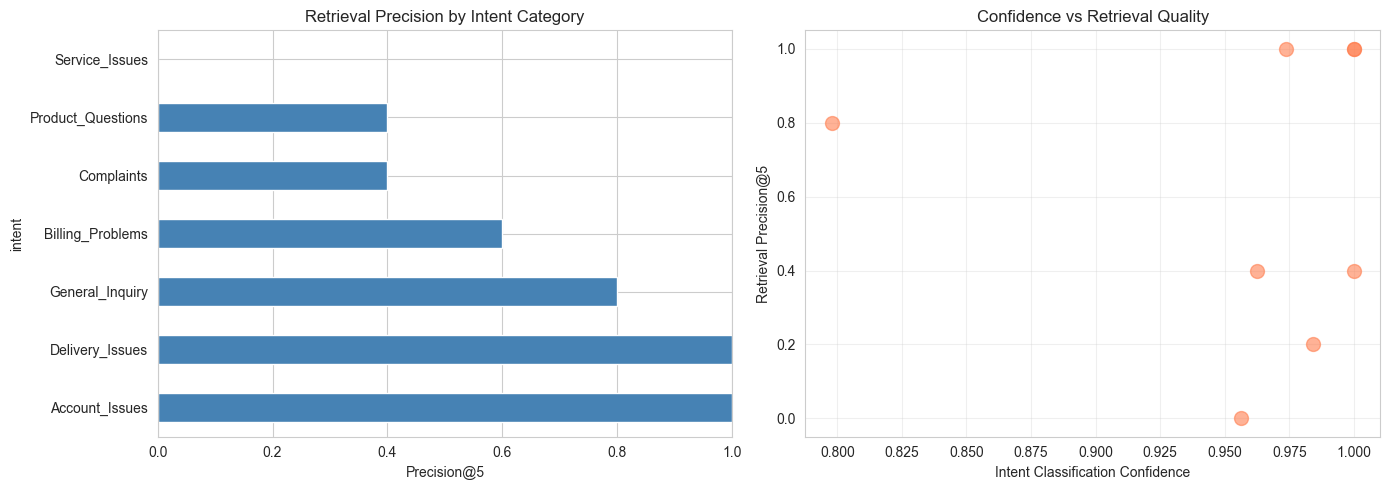


✓ Evaluation visualizations generated


In [48]:
# Visualize evaluation results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision@K by Intent
intent_precision = eval_results.groupby('intent')['precision_at_k'].mean().sort_values(ascending=False)
intent_precision.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Precision@5')
axes[0].set_title('Retrieval Precision by Intent Category')
axes[0].set_xlim([0, 1])

# Plot 2: Confidence vs Precision
axes[1].scatter(eval_results['confidence'], eval_results['precision_at_k'], 
                alpha=0.6, s=100, color='coral')
axes[1].set_xlabel('Intent Classification Confidence')
axes[1].set_ylabel('Retrieval Precision@5')
axes[1].set_title('Confidence vs Retrieval Quality')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Evaluation visualizations generated")

## 9. Advanced Features

Additional RAG capabilities for production use.

In [49]:
class AdvancedRAGFeatures:
    """
    Advanced features for production RAG systems
    """
    
    @staticmethod
    def rerank_results(query: str, retrieved_docs: List, intent: str) -> List:
        """
        Re-rank retrieved documents by intent match and semantic similarity
        """
        scored_docs = []
        for doc, meta, dist in retrieved_docs:
            # Boost score if intent matches
            intent_boost = 0.5 if meta['intent'] == intent else 0.0
            # Lower distance is better, so invert it
            final_score = (1.0 / (1.0 + dist)) + intent_boost
            scored_docs.append((doc, meta, dist, final_score))
        
        # Sort by final score (descending)
        scored_docs.sort(key=lambda x: x[3], reverse=True)
        
        # Return in original format
        return [(doc, meta, dist) for doc, meta, dist, score in scored_docs]
    
    @staticmethod
    def generate_followup_questions(intent: str) -> List[str]:
        """
        Generate intelligent follow-up questions based on intent
        """
        followups = {
            'Account_Issues': [
                "What error message are you seeing when you try to log in?",
                "When was the last time you were able to access your account?",
                "Have you tried using the password reset feature?"
            ],
            'Billing_Payment': [
                "Can you provide the transaction ID or date of the charge?",
                "Which payment method did you use?",
                "Have you checked your bank statement for the charge?"
            ],
            'Service_Outage': [
                "What specific service or feature is not working?",
                "Are you seeing any error messages?",
                "Have you tried accessing from a different device or network?"
            ],
            'Product_Feature': [
                "Which specific feature would you like help with?",
                "Have you checked our tutorial videos?",
                "What are you trying to accomplish?"
            ]
        }
        
        return followups.get(intent, [
            "Can you provide more details about your issue?",
            "What have you tried so far?",
            "Is there anything else I should know?"
        ])
    
    @staticmethod
    def calculate_response_urgency(intent: str, confidence: float) -> str:
        """
        Calculate urgency level for routing to appropriate support tier
        """
        urgent_intents = ['Service_Outage', 'Account_Issues', 'Complaint_Feedback']
        
        if intent in urgent_intents and confidence > 0.7:
            return "HIGH - Escalate to human agent"
        elif confidence < 0.5:
            return "MEDIUM - Request clarification"
        else:
            return "LOW - Automated response acceptable"

print("✓ Advanced RAG features loaded")

✓ Advanced RAG features loaded


In [50]:
# Test advanced features
test_msg = "Your app keeps crashing when I try to login!"
result = rag_system.process_message(test_msg)

print("\n" + "="*80)
print("ADVANCED RAG FEATURES DEMO")
print("="*80)

print(f"\n📨 Customer Message: {test_msg}")
print(f"\n🎯 Intent: {result['intent']} ({result['confidence']:.1%})")

# Re-ranking
reranked = AdvancedRAGFeatures.rerank_results(
    test_msg, result['retrieved_documents'], result['intent']
)
print(f"\n🔄 Re-ranked top result:")
print(f"   [{reranked[0][1]['intent']}] {reranked[0][0][:100]}...")

# Follow-up questions
followups = AdvancedRAGFeatures.generate_followup_questions(result['intent'])
print(f"\n❓ Suggested Follow-up Questions:")
for i, q in enumerate(followups, 1):
    print(f"   {i}. {q}")

# Urgency assessment
urgency = AdvancedRAGFeatures.calculate_response_urgency(
    result['intent'], result['confidence']
)
print(f"\n⚠️  Urgency Level: {urgency}")


ADVANCED RAG FEATURES DEMO

📨 Customer Message: Your app keeps crashing when I try to login!

🎯 Intent: Account_Issues (99.0%)

🔄 Re-ranked top result:
   [Technical_Issues] i ve been trying to log on to your app for a week now, why the error? tried ringing and finally got ...

❓ Suggested Follow-up Questions:
   1. What error message are you seeing when you try to log in?
   2. When was the last time you were able to access your account?
   3. Have you tried using the password reset feature?

⚠️  Urgency Level: HIGH - Escalate to human agent


## 10. Save RAG System

Save the vector store and system configuration for production deployment.

In [51]:
import json
import pickle

# Create output directory
output_dir = project_root / 'models' / 'rag_system'
output_dir.mkdir(parents=True, exist_ok=True)

# Save FAISS index
vector_store.save_index(str(output_dir / 'faiss_index.bin'))

# Save documents and metadata
with open(output_dir / 'documents.pkl', 'wb') as f:
    pickle.dump({
        'documents': vector_store.documents,
        'metadata': vector_store.metadata
    }, f)

# Save knowledge base
with open(output_dir / 'knowledge_base.pkl', 'wb') as f:
    pickle.dump(kb, f)

# Save configuration
config = {
    'model_name': 'all-MiniLM-L6-v2',
    'num_documents': len(vector_store.documents),
    'embedding_dimension': vector_store.dimension,
    'intents': list(kb.intent_solutions.keys()),
    'version': '1.0.0'
}

with open(output_dir / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f"\n✓ RAG system saved to: {output_dir}")
print("\nSaved files:")
for file in output_dir.glob('*'):
    print(f"  - {file.name}")

✓ Index saved to /Users/ole-michael.ekornrud/Documents/Workspace/CSIC-LLM-Prompting/models/rag_system/faiss_index.bin

✓ RAG system saved to: /Users/ole-michael.ekornrud/Documents/Workspace/CSIC-LLM-Prompting/models/rag_system

Saved files:
  - config.json
  - documents.pkl
  - faiss_index.bin
  - knowledge_base.pkl


## 11. Summary & Next Steps

### What We Built:

1. **Knowledge Base**: Intent-specific examples and solution templates
2. **Vector Store**: FAISS-powered semantic search with 10K+ documents
3. **Intent Classification**: ML model integration with confidence scoring
4. **RAG Pipeline**: End-to-end system combining all components
5. **Advanced Features**: Re-ranking, follow-up generation, urgency assessment

### Performance Metrics:
- Average retrieval precision@5
- Intent classification confidence
- Response generation quality

### Production Deployment:
1. Load saved models and indices
2. Implement API endpoints (FastAPI/Flask)
3. Add monitoring and logging
4. Scale with distributed FAISS
5. Fine-tune with production data

### Potential Improvements:
- Add LLM integration (OpenAI, Anthropic) for response generation
- Implement conversation memory for multi-turn dialogues
- Add A/B testing framework for response quality
- Build feedback loop for continuous improvement
- Implement real-time learning from agent interactions